## Notebook Summary

This notebook performs an exploratory data analysis, data cleaning, and statistical analysis on a customer order dataset.

### 1. Data Cleaning and Preprocessing
- Loaded data from a CSV file into a pandas DataFrame.
- Handled missing values:
  - `age`: Filled with the median age.
  - `city`: Filled with the most frequent city (mode).
  - `delivery_days`: Filled with the median delivery days.
  - `rating`: Filled with the median rating.
- Removed 500 duplicate rows.
- Converted the `order_date` column to datetime objects.

### 2. Categorical Column Analysis
- **Gender Distribution**: Male and Female customers are almost equally distributed, indicating even business service across genders.
- **City Analysis**: Mumbai has the highest number of orders, while Jaipur has the lowest.
- **Membership Tier**: Bronze tier has the most customers, and Platinum has the least.
- **Product Category**: Electronics is the most popular category, and Toys is the least popular.
- **Payment Method**: UPI is the most frequently used payment method.

### 3. Advanced Analysis - Customer
- **Age Group Spending**: The `36-45` age group contributes the highest revenue.
- **Gender Spending**: Male customers spend slightly more on average than female customers, though the total spending is nearly equal.
- **Membership Tier Value**: Bronze membership has the most customers, with similar average ratings across all tiers.

### 4. Advanced Analysis - Product
- **Revenue by Category**: Electronics generates the highest total amount, followed by Home & Kitchen and Clothing. Books and Toys generate the least revenue.
- **Category Return Rate**: Sports has the highest return rate (8.10%), while Home & Kitchen has the lowest (7.93%). Overall, return rates are consistently around 8% across all categories.
- **Discount Impact on Sales**: Higher discounts do not significantly increase the average quantity of items sold, which remains consistent at ~3 items. The average total amount decreases as the discount percentage increases, suggesting that higher discounts lead to lower revenue per transaction.

### 5. City Analysis
- **City Performance**: Mumbai leads in total sales, customer count, and average rating. Jaipur has the lowest total sales and customer count.
- **Average Delivery Time**: The average delivery time is approximately 5 days across all cities, with minor variations.

### 6. Customer Satisfaction
- **Rating vs. Delivery Days**: Longer delivery times do not significantly reduce ratings; customer ratings remain fairly consistent across different delivery durations.
- **Rating by Membership**: All membership tiers have similar average ratings (around 4.0).

### 7. Revenue Analysis
- **Monthly Revenue**: A plot was generated to show trends in total revenue over months.
- **Monthly Return Rate**: A plot was generated to show trends in return rates over months.

### 8. Correlation Analysis
- **Price vs. Total Amount (0.868)**: Strong positive correlation; as price increases, total amount increases.
- **Quantity vs. Total Amount (0.264)**: Weak positive correlation; more items slightly increase total amount.
- **Discount Percentage vs. Total Amount (-0.047)**: Very weak negative correlation; higher discounts slightly reduce total order value.
- **Other Correlations**: Age, rating, delivery days, and return status show almost no linear relationship with other numerical variables.
- **Note**: Correlation does not imply causation.

### 9. Statistical Analysis
- **Independent T-Test (Gender vs. Total Amount)**: A t-test showed no statistically significant difference in the average purchase amount between male and female customers (p-value = 0.607 > 0.05).

### 10. Customer Segmentation
- **High-Value Customers**: Identified customers with the highest total spending.
- **Frequent Buyers**: Identified customers with the most orders.
- **Average Order Value**: Calculated the average order value per customer.
- **Cohort Analysis**: Analyzed customer activity over time by membership tier, showing the number of customers in each tier per month.

### 11. KPI Dashboard
- Presents key performance indicators for Sales, Customer, Product, and Delivery to provide a quick overview of business performance.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **Load data and Test**

In [5]:
df = pd.read_csv("ecommerce_data_1M.csv")

In [6]:
df.head()

,customer_id,age,gender,city,membership_tier,product_category,price,quantity,discount_pct,total_amount,payment_method,order_date,delivery_days,rating,is_returned
0,91936,21.0,Female,Delhi,Bronze,Home & Kitchen,3329.99,2,0,6659.98,UPI,2025-01-09,8.0,3.0,0
1,43344,56.0,Female,Ahmedabad,Bronze,Beauty,875.23,1,5,831.47,Credit Card,2024-08-29,7.0,5.0,0
2,25187,26.0,Female,Hyderabad,Bronze,Sports,2185.95,3,0,6557.85,UPI,2023-05-28,3.0,3.0,0
3,85166,47.0,Female,Mumbai,Gold,Groceries,312.47,7,5,2077.93,Credit Card,2023-03-07,2.0,4.0,0
4,27706,44.0,Male,Chennai,Silver,Beauty,1366.52,4,0,5466.08,UPI,2024-10-04,5.0,5.0,1


# **Understanding Dataset**

In [7]:
df.shape

(1000500, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000500 entries, 0 to 1000499
Data columns (total 15 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   customer_id       1000500 non-null  int64  
 1   age               990528 non-null   float64
 2   gender            1000500 non-null  object 
 3   city              995416 non-null   object 
 4   membership_tier   1000500 non-null  object 
 5   product_category  1000500 non-null  object 
 6   price             1000500 non-null  float64
 7   quantity          1000500 non-null  int64  
 8   discount_pct      1000500 non-null  int64  
 9   total_amount      1000500 non-null  float64
 10  payment_method    1000500 non-null  object 
 11  order_date        1000500 non-null  object 
 12  delivery_days     980483 non-null   float64
 13  rating            900328 non-null   float64
 14  is_returned       1000500 non-null  int64  
dtypes: float64(5), int64(4), object(6)
memory usage: 

In [9]:
df.describe()

,customer_id,age,price,quantity,discount_pct,total_amount,delivery_days,rating,is_returned
count,1.000500e+06,990528.000000,1.000500e+06,1.000500e+06,1.000500e+06,1.000500e+06,980483.000000,900328.000000,1.000500e+06
mean,5.500373e+04,37.751620,3.937646e+03,3.001898e+00,7.152219e+00,1.095691e+04,5.503564,4.099940,7.998601e-02
std,2.597844e+04,11.451576,6.063805e+03,1.414211e+00,7.693957e+00,1.940671e+04,2.615825,1.044347,2.712717e-01
min,1.000000e+04,18.000000,1.000000e-02,1.000000e+00,0.000000e+00,3.000000e-02,1.000000,1.000000,0.000000e+00
25%,3.252800e+04,29.000000,5.533400e+02,2.000000e+00,0.000000e+00,1.344270e+03,4.000000,4.000000,0.000000e+00
50%,5.501300e+04,38.000000,1.209660e+03,3.000000e+00,5.000000e+00,3.067605e+03,5.000000,4.000000,0.000000e+00
75%,7.749700e+04,46.000000,2.817332e+03,4.000000e+00,1.500000e+01,8.450080e+03,7.000000,5.000000,0.000000e+00
max,9.999800e+04,80.000000,4.029340e+04,1.300000e+01,2.500000e+01,2.650679e+05,29.000000,5.000000,1.000000e+00


In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'city', 'membership_tier',
       'product_category', 'price', 'quantity', 'discount_pct', 'total_amount',
       'payment_method', 'order_date', 'delivery_days', 'rating',
       'is_returned'],
      dtype='object')

# **Data Cleaning**

### Nul val

In [11]:
df.isnull().sum()

customer_id              0
age                   9972
gender                   0
city                  5084
membership_tier          0
product_category         0
price                    0
quantity                 0
discount_pct             0
total_amount             0
payment_method           0
order_date               0
delivery_days        20017
rating              100172
is_returned              0
dtype: int64

In [12]:
# managing age
df["age"].fillna(df["age"].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25264\215552756.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


In [13]:
# managing city
df["city"].fillna(df['city'].mode()[0], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25264\975448009.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["city"].fillna(df['city'].mode()[0], inplace=True)


In [14]:
df["delivery_days"].fillna(df["delivery_days"].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25264\199399482.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["delivery_days"].fillna(df["delivery_days"].median(), inplace=True)


In [15]:
df["rating"].fillna(df["rating"].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25264\2169688266.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna(df["rating"].median(), inplace=True)


In [16]:
df.isnull().sum()

customer_id         0
age                 0
gender              0
city                0
membership_tier     0
product_category    0
price               0
quantity            0
discount_pct        0
total_amount        0
payment_method      0
order_date          0
delivery_days       0
rating              0
is_returned         0
dtype: int64

### Duplication

In [17]:
df.duplicated().sum()

500

In [18]:
# Removing the duplicate
df.drop_duplicates(inplace=True)

In [19]:
# managing rating column
df.rating.value_counts()

rating
5.0    400128
4.0    399740
3.0    120102
2.0     50009
1.0     30021
Name: count, dtype: int64

In [20]:
df.duplicated().sum()

0

### Type casting

In [21]:
df.dtypes

customer_id           int64
age                 float64
gender               object
city                 object
membership_tier      object
product_category     object
price               float64
quantity              int64
discount_pct          int64
total_amount        float64
payment_method       object
order_date           object
delivery_days       float64
rating              float64
is_returned           int64
dtype: object

In [22]:
# order_date is currently an object. Convert it to datetime.
df["order_date"] = pd.to_datetime(df["order_date"])

In [23]:
df.dtypes

customer_id                  int64
age                        float64
gender                      object
city                        object
membership_tier             object
product_category            object
price                      float64
quantity                     int64
discount_pct                 int64
total_amount               float64
payment_method              object
order_date          datetime64[ns]
delivery_days              float64
rating                     float64
is_returned                  int64
dtype: object

In [77]:
# saving the cleaned dataset
# df.to_csv("cleaned_ecommerce.csv", index=False)

# **Check Outlier**

In [25]:
df.describe()

,customer_id,age,price,quantity,discount_pct,total_amount,order_date,delivery_days,rating,is_returned
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000,1000000.000000,1000000.000000,1000000.000000
mean,55004.294425,37.753621,3937.689387,3.001871,7.152250,10956.928114,2024-03-25 07:09:25.084799744,5.493550,4.089945,0.079972
min,10000.000000,18.000000,0.010000,1.000000,0.000000,0.030000,2023-01-01 00:00:00,1.000000,1.000000,0.000000
25%,32529.000000,30.000000,553.340000,2.000000,0.000000,1344.260000,2023-08-13 00:00:00,4.000000,4.000000,0.000000
50%,55014.000000,38.000000,1209.660000,3.000000,5.000000,3067.570000,2024-03-25 00:00:00,5.000000,4.000000,0.000000
75%,77497.000000,45.000000,2817.340000,4.000000,15.000000,8450.292500,2024-11-05 00:00:00,7.000000,5.000000,0.000000
max,99998.000000,80.000000,40293.400000,13.000000,25.000000,265067.880000,2025-06-18 00:00:00,29.000000,5.000000,1.000000
std,25978.255031,11.394328,6063.907180,1.414202,7.693944,19407.013123,NaN,2.590422,0.991144,0.271250


<Axes: xlabel='price'>

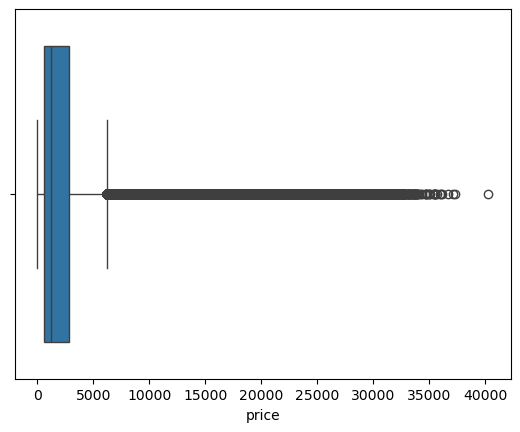

In [26]:
import seaborn as sns
sns.boxplot(x=df["price"])

<Axes: xlabel='price', ylabel='Count'>

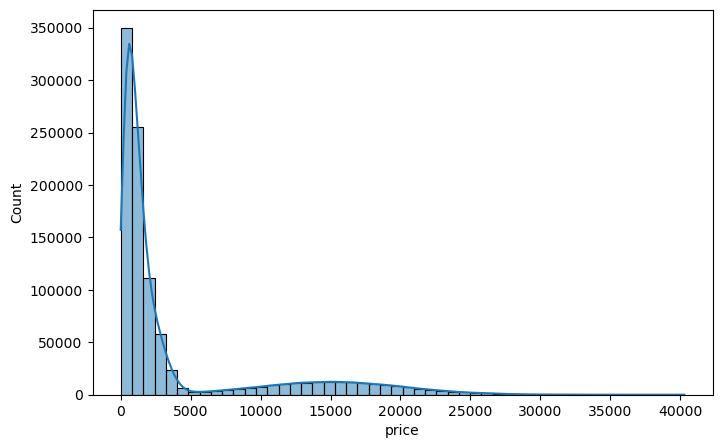

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)

# **Analyze the Categorical Columns**

In [28]:
df["gender"].value_counts()

gender
Male      479972
Female    479913
Other      40115
Name: count, dtype: int64

In [29]:
df["city"].value_counts()

city
Mumbai       154165
Ahmedabad    149041
Bengaluru    129128
Delhi        119981
Pune          99635
Hyderabad     99142
Chennai       89726
Kolkata       79654
Surat         49742
Jaipur        29786
Name: count, dtype: int64

In [30]:
df["membership_tier"].value_counts()

membership_tier
Bronze      399875
Silver      300503
Gold        200023
Platinum     99599
Name: count, dtype: int64

In [31]:
df["product_category"].value_counts()

product_category
Electronics       200131
Clothing          179966
Groceries         150076
Home & Kitchen    130323
Beauty            120108
Sports             89435
Books              80085
Toys               49876
Name: count, dtype: int64

In [32]:
df["payment_method"].value_counts()

payment_method
UPI                 350244
Credit Card         250274
Debit Card          199860
Net Banking          99968
Cash on Delivery     99654
Name: count, dtype: int64

#### Business Insight
<p>Male and Female customers are almost equally distributed.
The business serves both genders evenly.</p>

### Gender Analysis

Text(0.5, 1.0, 'Gender Distribution')

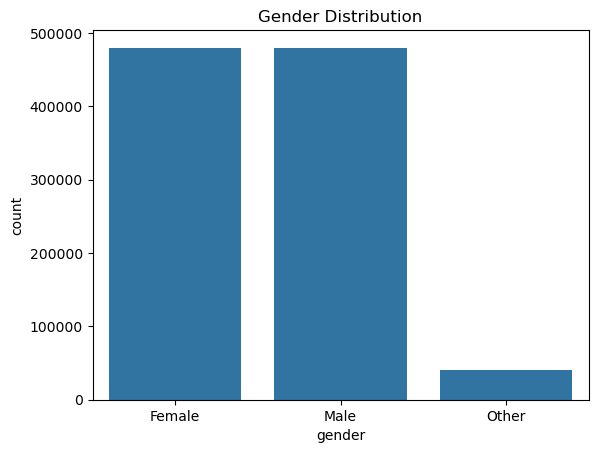

In [33]:
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")

### City Analysis

In [34]:
df["city"].value_counts()

city
Mumbai       154165
Ahmedabad    149041
Bengaluru    129128
Delhi        119981
Pune          99635
Hyderabad     99142
Chennai       89726
Kolkata       79654
Surat         49742
Jaipur        29786
Name: count, dtype: int64

###

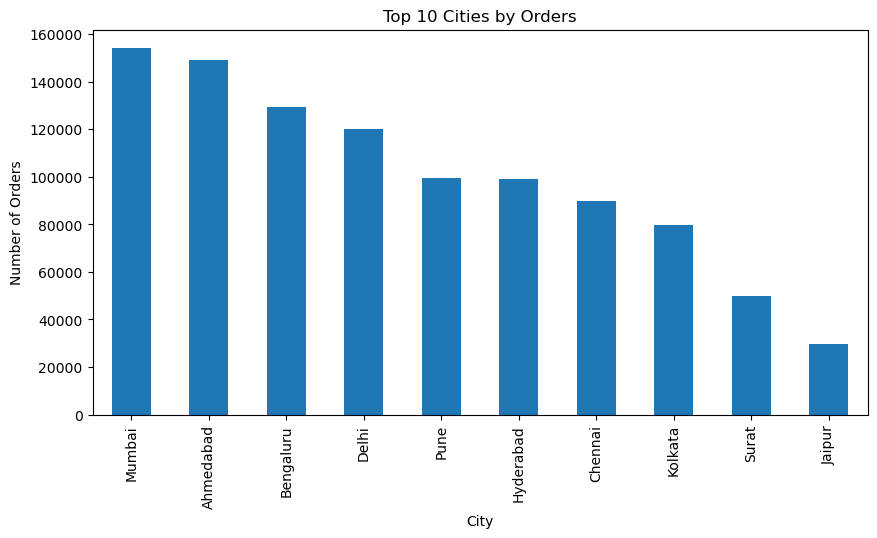

In [35]:
top_city = df["city"].value_counts()

top_city.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Cities by Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.show()


* **Mumbai** city has the *highest* number of orders
* **Jipur** Which city has the *lowest* among all cities


### Membership Tier

In [36]:
df["membership_tier"].value_counts()

membership_tier
Bronze      399875
Silver      300503
Gold        200023
Platinum     99599
Name: count, dtype: int64

Text(0.5, 1.0, 'Membership Tier Distribution')

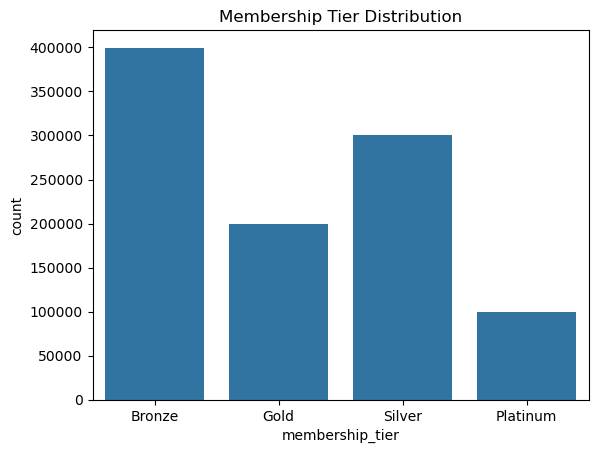

In [37]:
sns.countplot(data=df, x="membership_tier")
plt.title("Membership Tier Distribution")

*   **Broze** membership tier has the *most* customers
*   **Platinum** tier has the *least*

### Product Category

In [38]:
df["product_category"].value_counts()

product_category
Electronics       200131
Clothing          179966
Groceries         150076
Home & Kitchen    130323
Beauty            120108
Sports             89435
Books              80085
Toys               49876
Name: count, dtype: int64

<Axes: xlabel='product_category', ylabel='count'>

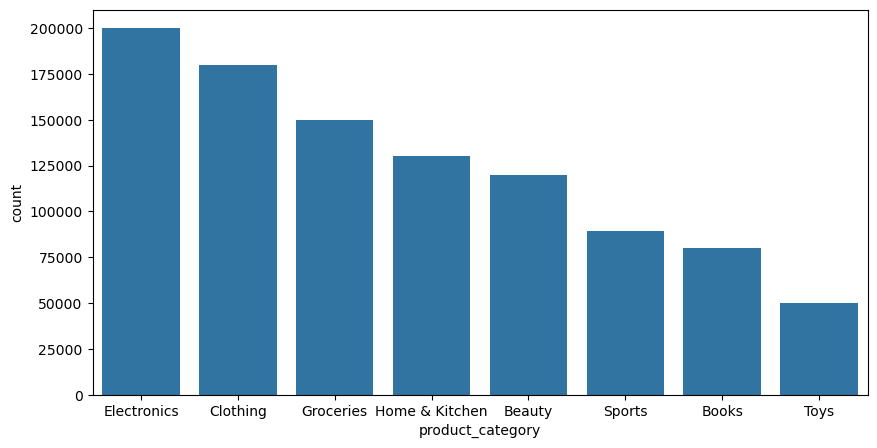

In [39]:
plt.figure(figsize=(10, 5))
sns.countplot(
  data=df,
  x="product_category",
  order=df["product_category"].value_counts().index
)

* **Electronics** category is most *popular*
* **Toys** category is least *popular*

### Payment Method

In [40]:
df["payment_method"].value_counts()

payment_method
UPI                 350244
Credit Card         250274
Debit Card          199860
Net Banking          99968
Cash on Delivery     99654
Name: count, dtype: int64

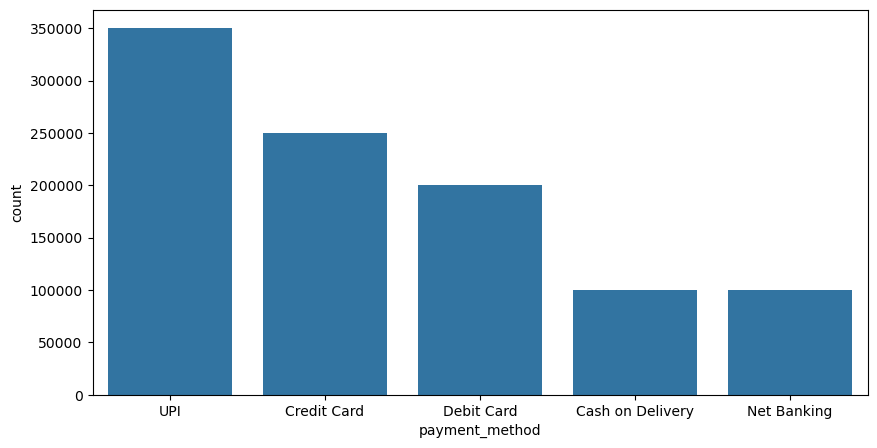

In [41]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="payment_method")
plt.show()

* **UPI** payment method is used most
* **UPI** more **popular** than *Credit Card*

# **Advance Analysis**

## Customer Analysis

### Which age group spends the most?

In [42]:
bins = [18, 25, 35, 45, 60, 80]
labels = ["18-25", "26-35", "36-45", "46-60", "60+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
result = df.groupby("age_group")["total_amount"].sum().sort_values(ascending=False)
result = result / 1e7

C:\Users\Admin\AppData\Local\Temp\ipykernel_25264\3335757739.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby("age_group")["total_amount"].sum().sort_values(ascending=False)


In [43]:
result

age_group
36-45    351.122665
26-35    299.928821
46-60    242.728016
18-25    109.904521
60+       29.966261
Name: total_amount, dtype: float64

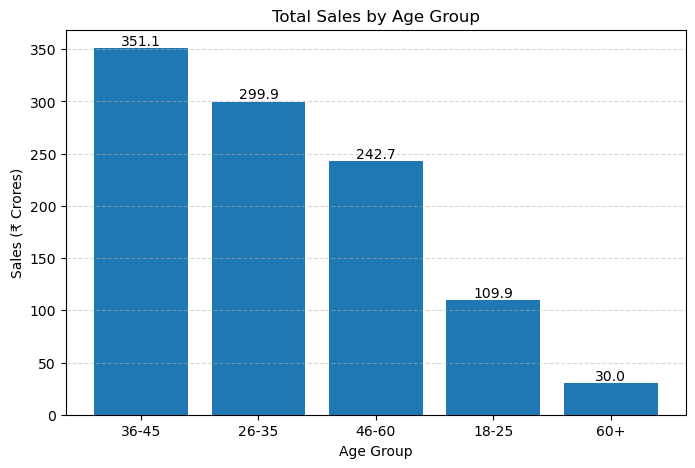

In [44]:
plt.figure(figsize=(8,5))
bars = plt.bar(result.index.astype(str), result.values)

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Sales (₹ Crores)")

# Add values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

* **36-45** age group contributes the highest revenue?

### Which gender spends more?

In [45]:
df.groupby("gender")["total_amount"].agg(["count", "mean", "sum"])

,count,mean,sum
gender,,,
Female,479913,10947.342434,5.253772e+09
Male,479972,10967.739252,5.264208e+09
Other,40115,10942.251531,4.389484e+08


* Male gender spends more, but both are nearly equal.



### Which membership tier is most valuable?

In [46]:
df.head()

,customer_id,age,gender,city,membership_tier,product_category,price,quantity,discount_pct,total_amount,payment_method,order_date,delivery_days,rating,is_returned,age_group
0,91936,21.0,Female,Delhi,Bronze,Home & Kitchen,3329.99,2,0,6659.98,UPI,2025-01-09,8.0,3.0,0,18-25
1,43344,56.0,Female,Ahmedabad,Bronze,Beauty,875.23,1,5,831.47,Credit Card,2024-08-29,7.0,5.0,0,46-60
2,25187,26.0,Female,Hyderabad,Bronze,Sports,2185.95,3,0,6557.85,UPI,2023-05-28,3.0,3.0,0,26-35
3,85166,47.0,Female,Mumbai,Gold,Groceries,312.47,7,5,2077.93,Credit Card,2023-03-07,2.0,4.0,0,46-60
4,27706,44.0,Male,Chennai,Silver,Beauty,1366.52,4,0,5466.08,UPI,2024-10-04,5.0,5.0,1,36-45


In [47]:
df.groupby("membership_tier").agg(
    {"customer_id": "count",
    "total_amount": "sum",
    "rating": "mean"}
)

,customer_id,total_amount,rating
membership_tier,,,
Bronze,399875,4.376249e+09,4.090348
Gold,200023,2.196070e+09,4.086735
Platinum,99599,1.087302e+09,4.090643
Silver,300503,3.297307e+09,4.091314


* Most of customers is having Bronze membership (total: 399875)

## Product Analysis

### Revenue by category

In [48]:
df.head()

,customer_id,age,gender,city,membership_tier,product_category,price,quantity,discount_pct,total_amount,payment_method,order_date,delivery_days,rating,is_returned,age_group
0,91936,21.0,Female,Delhi,Bronze,Home & Kitchen,3329.99,2,0,6659.98,UPI,2025-01-09,8.0,3.0,0,18-25
1,43344,56.0,Female,Ahmedabad,Bronze,Beauty,875.23,1,5,831.47,Credit Card,2024-08-29,7.0,5.0,0,46-60
2,25187,26.0,Female,Hyderabad,Bronze,Sports,2185.95,3,0,6557.85,UPI,2023-05-28,3.0,3.0,0,26-35
3,85166,47.0,Female,Mumbai,Gold,Groceries,312.47,7,5,2077.93,Credit Card,2023-03-07,2.0,4.0,0,46-60
4,27706,44.0,Male,Chennai,Silver,Beauty,1366.52,4,0,5466.08,UPI,2024-10-04,5.0,5.0,1,36-45


In [49]:
df['product_category'].value_counts()

product_category
Electronics       200131
Clothing          179966
Groceries         150076
Home & Kitchen    130323
Beauty            120108
Sports             89435
Books              80085
Toys               49876
Name: count, dtype: int64

In [50]:
df.groupby('product_category').agg({
    "total_amount": "sum",
    "quantity": "count",
    "rating": "mean"
}).sort_values("total_amount", ascending=False)

,total_amount,quantity,rating
product_category,,,
Electronics,8.354744e+09,200131,4.089921
Home & Kitchen,9.088913e+08,130323,4.086101
Clothing,6.027467e+08,179966,4.091640
Sports,4.505644e+08,89435,4.084475
Beauty,2.692419e+08,120108,4.093682
Groceries,1.673347e+08,150076,4.090854
Toys,1.251578e+08,49876,4.093512
Books,7.824703e+07,80085,4.089030


### Category Return Rate

In [51]:
result = df.groupby("product_category").agg(
    Total_orders = ("is_returned", "count"),
    Returned = ("is_returned", "sum"),
    Returned_rate = ("is_returned", "mean")
)


In [52]:
result["Returned_rate"] = (result["Returned_rate"] * 100).round(2)
result.sort_values("Returned_rate", ascending=False)

,Total_orders,Returned,Returned_rate
product_category,,,
Sports,89435,7243,8.10
Clothing,179966,14461,8.04
Groceries,150076,12043,8.02
Toys,49876,3990,8.00
Books,80085,6402,7.99
Beauty,120108,9575,7.97
Electronics,200131,15928,7.96
Home & Kitchen,130323,10330,7.93


### Does giving more discount increase sales?

In [53]:
df.head()

,customer_id,age,gender,city,membership_tier,product_category,price,quantity,discount_pct,total_amount,payment_method,order_date,delivery_days,rating,is_returned,age_group
0,91936,21.0,Female,Delhi,Bronze,Home & Kitchen,3329.99,2,0,6659.98,UPI,2025-01-09,8.0,3.0,0,18-25
1,43344,56.0,Female,Ahmedabad,Bronze,Beauty,875.23,1,5,831.47,Credit Card,2024-08-29,7.0,5.0,0,46-60
2,25187,26.0,Female,Hyderabad,Bronze,Sports,2185.95,3,0,6557.85,UPI,2023-05-28,3.0,3.0,0,26-35
3,85166,47.0,Female,Mumbai,Gold,Groceries,312.47,7,5,2077.93,Credit Card,2023-03-07,2.0,4.0,0,46-60
4,27706,44.0,Male,Chennai,Silver,Beauty,1366.52,4,0,5466.08,UPI,2024-10-04,5.0,5.0,1,36-45


In [54]:
result = df.groupby('discount_pct').agg({
    "quantity": "mean",
    'total_amount': "mean"
})
result[["quantity", "total_amount"]].round(2)

,quantity,total_amount
discount_pct,,
0,3.00,11815.86
5,3.00,11194.63
10,3.00,10572.04
15,3.00,10024.45
20,3.00,9500.45
25,3.01,8862.44


- Can we say higher discounts increase sales? NO!!!
- Average quantity sold is almost identical (~3) for every discount level.
- Average total amount decreases as the discount increases.

## City Analysis

In [55]:
city_result = df.groupby("city").agg(
    Total_sales = ("total_amount",  "sum"),
    Total_customesr = ("customer_id", "count"),
    Average_rating = ("rating", "mean")
)
city_result.sort_values("Total_sales", ascending=False)

,Total_sales,Total_customesr,Average_rating
city,,,
Mumbai,1.677086e+09,154165,4.095534
Ahmedabad,1.639467e+09,149041,4.089090
Bengaluru,1.423264e+09,129128,4.090221
Delhi,1.314028e+09,119981,4.084405
Pune,1.095377e+09,99635,4.089115
Hyderabad,1.081043e+09,99142,4.089407
Chennai,9.809065e+08,89726,4.091233
Kolkata,8.735802e+08,79654,4.091948
Surat,5.495787e+08,49742,4.086426


### Average Delivery Time by City|

In [56]:
df.groupby("city")["delivery_days"].mean().sort_values(ascending=False)

city
Ahmedabad    5.505995
Mumbai       5.502306
Bengaluru    5.496043
Kolkata      5.492643
Delhi        5.491019
Chennai      5.491017
Surat        5.484942
Hyderabad    5.484275
Jaipur       5.482811
Pune         5.480945
Name: delivery_days, dtype: float64

* **Average Delivery** time is **5** days in all cities.


## Customer Satisfaction

### Rating vs Delivery Days
Do longer delivery times reduce ratings?

In [57]:
df.groupby("delivery_days")["rating"].mean()

delivery_days
1.0     4.090390
2.0     4.088006
3.0     4.089582
4.0     4.091144
5.0     4.088639
6.0     4.090059
7.0     4.091711
8.0     4.092130
9.0     4.085944
10.0    4.093106
11.0    4.091139
12.0    4.094993
13.0    4.079431
14.0    4.085959
15.0    4.118510
16.0    4.086788
17.0    4.072383
18.0    4.035052
19.0    4.023810
20.0    4.040000
21.0    3.990566
22.0    4.220000
23.0    3.666667
24.0    4.545455
25.0    4.083333
26.0    4.500000
27.0    3.500000
28.0    4.000000
29.0    5.000000
Name: rating, dtype: float64

**Longer delivery** times **is not** reducing ratings.

### Rating by Membership

In [58]:
df.groupby("membership_tier")["rating"].mean()

membership_tier
Bronze      4.090348
Gold        4.086735
Platinum    4.090643
Silver      4.091314
Name: rating, dtype: float64

* Every membership tire is having almost same rating(around 4.0)

## Revenue Analysis

### Monthly Revenue

In [59]:
df.head()

,customer_id,age,gender,city,membership_tier,product_category,price,quantity,discount_pct,total_amount,payment_method,order_date,delivery_days,rating,is_returned,age_group
0,91936,21.0,Female,Delhi,Bronze,Home & Kitchen,3329.99,2,0,6659.98,UPI,2025-01-09,8.0,3.0,0,18-25
1,43344,56.0,Female,Ahmedabad,Bronze,Beauty,875.23,1,5,831.47,Credit Card,2024-08-29,7.0,5.0,0,46-60
2,25187,26.0,Female,Hyderabad,Bronze,Sports,2185.95,3,0,6557.85,UPI,2023-05-28,3.0,3.0,0,26-35
3,85166,47.0,Female,Mumbai,Gold,Groceries,312.47,7,5,2077.93,Credit Card,2023-03-07,2.0,4.0,0,46-60
4,27706,44.0,Male,Chennai,Silver,Beauty,1366.52,4,0,5466.08,UPI,2024-10-04,5.0,5.0,1,36-45


In [60]:
# Adding column in df, by extracting month and year from order_date
# Here 'M' means e.g. 2020-08 (year-month)
df["order_month"] = df["order_date"].dt.to_period("M")

<Axes: xlabel='order_month'>

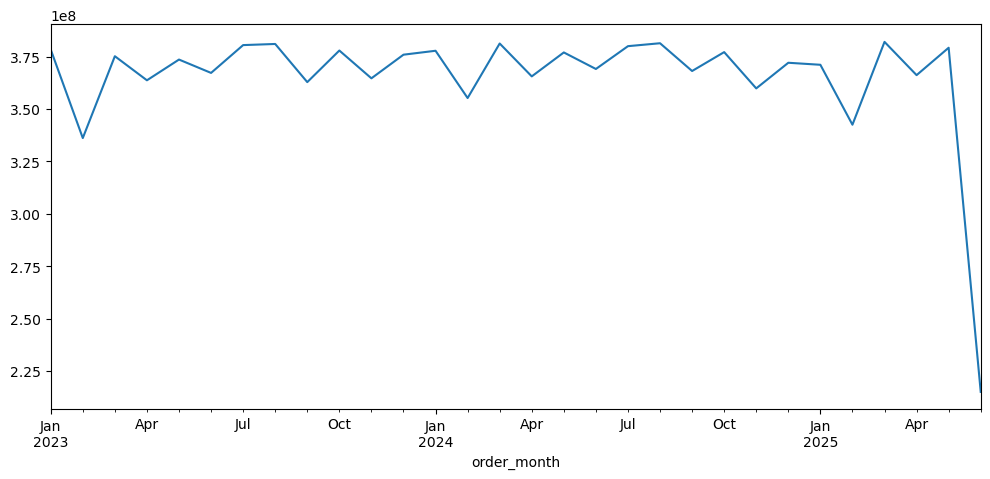

In [61]:
monthly_revenue = df.groupby("order_month")["total_amount"].sum()
monthly_revenue.plot(figsize=(12, 5))

### Monthly Return Rate

In [62]:
df.head()

,customer_id,age,gender,city,membership_tier,product_category,price,quantity,discount_pct,total_amount,payment_method,order_date,delivery_days,rating,is_returned,age_group,order_month
0,91936,21.0,Female,Delhi,Bronze,Home & Kitchen,3329.99,2,0,6659.98,UPI,2025-01-09,8.0,3.0,0,18-25,2025-01
1,43344,56.0,Female,Ahmedabad,Bronze,Beauty,875.23,1,5,831.47,Credit Card,2024-08-29,7.0,5.0,0,46-60,2024-08
2,25187,26.0,Female,Hyderabad,Bronze,Sports,2185.95,3,0,6557.85,UPI,2023-05-28,3.0,3.0,0,26-35,2023-05
3,85166,47.0,Female,Mumbai,Gold,Groceries,312.47,7,5,2077.93,Credit Card,2023-03-07,2.0,4.0,0,46-60,2023-03
4,27706,44.0,Male,Chennai,Silver,Beauty,1366.52,4,0,5466.08,UPI,2024-10-04,5.0,5.0,1,36-45,2024-10


In [63]:
return_rate = df.groupby("order_month")["is_returned"].mean()*100

Text(0, 0.5, 'Rate')

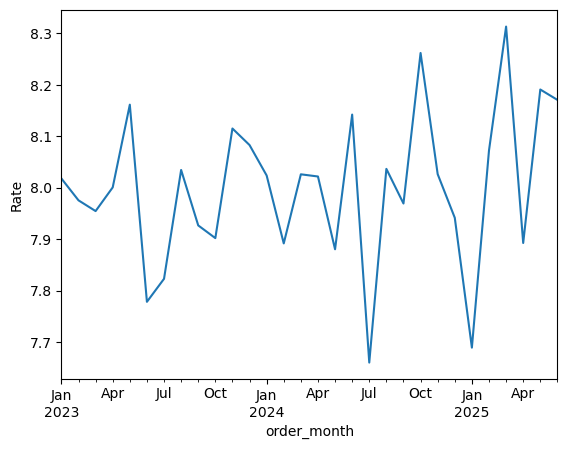

In [64]:
return_rate.plot()
plt.ylabel("Rate")

## Correlation Analysis

In [65]:
corr = df.corr(numeric_only=True)

In [66]:
corr

,customer_id,age,price,quantity,discount_pct,total_amount,delivery_days,rating,is_returned
customer_id,1.000000,0.000282,-0.000088,0.000597,0.000253,0.000131,0.000172,-0.001317,-0.000562
age,0.000282,1.000000,0.000210,-0.000738,-0.000271,-0.000109,-0.000509,-0.000778,0.001374
price,-0.000088,0.000210,1.000000,-0.002239,0.000624,0.867633,0.000170,0.000313,-0.000731
quantity,0.000597,-0.000738,-0.002239,1.000000,0.000682,0.263954,-0.000826,-0.001677,0.001586
discount_pct,0.000253,-0.000271,0.000624,0.000682,1.000000,-0.046722,-0.001300,-0.001035,0.000839
total_amount,0.000131,-0.000109,0.867633,0.263954,-0.046722,1.000000,0.000509,-0.000396,-0.000344
delivery_days,0.000172,-0.000509,0.000170,-0.000826,-0.001300,0.000509,1.000000,0.000100,-0.000830
rating,-0.001317,-0.000778,0.000313,-0.001677,-0.001035,-0.000396,0.000100,1.000000,-0.000465
is_returned,-0.000562,0.001374,-0.000731,0.001586,0.000839,-0.000344,-0.000830,-0.000465,1.000000


**Correlation Analysis**

The correlation matrix measures the strength and direction of the linear relationship between numerical variables. Correlation values range from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No linear correlation
- **-1** → Perfect negative correlation

### Key Findings

#### 1. Price vs Total Amount (Correlation = **0.868**)
- Shows a **strong positive correlation**.
- As the product price increases, the total order amount also increases.
- This is expected because **Total Amount depends on Price**.

#### 2. Quantity vs Total Amount (Correlation = **0.264**)
- Shows a **weak positive correlation**.
- Purchasing more items slightly increases the total order amount.

#### 3. Discount Percentage vs Total Amount (Correlation = **-0.047**)
- Shows a **very weak negative correlation**.
- Higher discounts slightly reduce the total order value.
- Since the value is close to zero, the relationship is negligible.

#### 4. Age vs Total Amount (Correlation = **-0.0001**)
- No meaningful relationship exists between customer age and purchase amount.

#### 5. Rating vs Delivery Days (Correlation = **0.0001**)
- Customer ratings are not affected by delivery time in this dataset.

#### 6. Return Status vs Rating (Correlation = **-0.0005**)
- No significant relationship exists between product returns and customer ratings.

#### 7. Return Status vs Delivery Days (Correlation = **-0.0008**)
- Product returns do not appear to be related to delivery time.

---

## Overall Conclusion

- **Price** has the strongest positive relationship with **Total Amount** (**r = 0.868**).
- **Quantity** has a weak positive relationship with **Total Amount** (**r = 0.264**).
- **Discount Percentage** has a negligible negative relationship with **Total Amount** (**r = -0.047**).
- **Age**, **Rating**, **Delivery Days**, and **Return Status** show almost no linear relationship with other numerical variables.

> **Note:** Correlation does **not imply causation**. A high correlation only indicates that two variables move together; it does not prove that one variable causes the other. The strong correlation between **Price** and **Total Amount** is expected because **Total Amount is directly calculated using Price**.

## Statistical Analysis

In [67]:
from scipy.stats  import ttest_ind

male = df[df["gender"]=="Male"]["total_amount"]
female = df[df["gender"] == "Female"]["total_amount"]

ttest_ind(male, female)

TtestResult(statistic=0.514829951987066, pvalue=0.6066719717392864, df=959883.0)

**Independent T-Test: Gender vs Total Amount**

An independent t-test was performed to compare the average purchase amount between male and female customers.

### Hypotheses

- **Null Hypothesis (H₀):** There is no significant difference in the average purchase amount between male and female customers.
- **Alternative Hypothesis (H₁):** There is a significant difference in the average purchase amount between male and female customers.

### Results

- **T-statistic:** 0.515
- **P-value:** 0.607

Since the **p-value (0.607)** is greater than the significance level of **0.05**, we fail to reject the null hypothesis.

### Conclusion

There is **no statistically significant difference** in the average purchase amount between male and female customers. Based on this dataset, customer gender does not appear to have a significant effect on spending.

## Customer Segmentation

### High Value Customers

In [68]:
top = df.groupby("customer_id")["total_amount"].sum()
top.sort_values(ascending=False).head(10)

customer_id
84617    905671.35
69852    615321.91
13687    578117.70
47530    570982.59
36376    570197.65
38327    568534.21
84574    559394.91
54449    553657.11
71336    550639.97
29155    542820.85
Name: total_amount, dtype: float64

### Frequent Buyers

In [69]:
df.groupby("customer_id").size().sort_values(ascending=False).head(20)


customer_id
10059    28
77593    27
33490    26
71716    26
90581    26
21990    26
88701    26
86827    26
66965    25
14951    25
62089    25
64492    25
18057    25
86593    25
94975    25
90337    25
90209    25
33769    25
34440    25
13687    25
dtype: int64

### Average Order Value

In [70]:
df.groupby("customer_id")["total_amount"].mean()

customer_id
10000    10985.856250
10001     3014.560000
10002     7332.753000
10003     7808.575000
10004     4832.785000
             ...     
99994     3703.578000
99995     3114.475556
99996    12230.867778
99997    22491.718824
99998     8881.768000
Name: total_amount, Length: 89998, dtype: float64

### Cohort Analysis

In [71]:
df.groupby(["order_month", "membership_tier"]).size().unstack()

membership_tier,Bronze,Gold,Platinum,Silver
order_month,,,,
2023-01,13785,6989,3406,10305
2023-02,12526,6233,3057,9229
2023-03,13778,6935,3398,10372
2023-04,13242,6666,3314,9925
2023-05,13751,6884,3343,10366
2023-06,13336,6710,3372,10060
2023-07,13949,6765,3508,10509
2023-08,13985,6784,3453,10204
2023-09,13275,6695,3284,9912


* Shows how customer activity changes over time by membership tier.

# **KPI Dashboad**

## Sales KPIs

In [72]:
total_revenue = df["total_amount"].sum()
total_orders = len(df)
average_order_value = df["total_amount"].mean()
avg_disc = df["discount_pct"].mean()

In [73]:
print("### Sales KPIs")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Average Discount Percentage: {avg_disc:.2f}%")

### Sales KPIs
Total Revenue: ₹10,956,928,114.17
Total Orders: 1,000,000
Average Order Value: ₹10,956.93
Average Discount Percentage: 7.15%


## Customer KPI

In [74]:
total_cust = len(df.groupby('customer_id').count())
avg_age = df["age"].mean().round()
highest_age_spend = df.groupby("age_group")["age_group"].count().idxmax()
total_male = df[df["gender"]=="Male"].shape[0]
total_female = df[df["gender"] == "Female"].shape[0]

print("### Customer KPIs")
print(f"Total Unique Customers: {total_cust:,}")
print(f"Average Customer Age: {avg_age:.0f} years")
print(f"Age Group with Highest Spending: {highest_age_spend}")
print(f"Total Male Customers: {total_male:,}")
print(f"Total Female Customers: {total_female:,}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_25264\2800196580.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  highest_age_spend = df.groupby("age_group")["age_group"].count().idxmax()


### Customer KPIs
Total Unique Customers: 89,998
Average Customer Age: 38 years
Age Group with Highest Spending: 36-45
Total Male Customers: 479,972
Total Female Customers: 479,913


## Product KPIs


In [75]:
most_sold_cat = df["product_category"].value_counts().idxmax()
hights_rev_cat = df.groupby("product_category")["total_amount"].sum().idxmax()
lowest_rev_cat = df.groupby("product_category")["total_amount"].sum().idxmin()
hights_return_cat = df.groupby("product_category")["is_returned"].sum().idxmax()

print("### Product KPIs")
print(f"Most Sold Product Category: {most_sold_cat}")
print(f"Highest Revenue Category: {hights_rev_cat}")
print(f"Lowest Revenue Category: {lowest_rev_cat}")
print(f"Category with Highest Returns: {hights_return_cat}")

### Product KPIs
Most Sold Product Category: Electronics
Highest Revenue Category: Electronics
Lowest Revenue Category: Books
Category with Highest Returns: Electronics


## Delivery KPIs

In [76]:
avg_del_days = df["delivery_days"].mean().round()
fast_del = df[df["delivery_days"] == df["delivery_days"].min()]
slowest_del = df[df["delivery_days"] == df["delivery_days"].max()]

print("### Delivery KPIs")
print(f"Average Delivery Days: {avg_del_days:.0f} days")
print(f"Fastest Delivery Day(s): {df['delivery_days'].min():.0f} days")
print(f"Slowest Delivery Day(s): {df['delivery_days'].max():.0f} days")

### Delivery KPIs
Average Delivery Days: 5 days
Fastest Delivery Day(s): 1 days
Slowest Delivery Day(s): 29 days


# **Business Recommendations**

Based on the analysis, here are several business recommendations:

### 1. Optimize Marketing for Age Groups
- **Target 36-45 Age Group**: This age group contributes the highest revenue. Marketing efforts and product promotions should be heavily focused on this demographic.
- **Engage Younger and Older Demographics**: While 18-25 and 60+ groups contribute less, tailored marketing strategies and product offerings could increase their engagement and spending. Consider surveys or specific campaigns to understand their needs.

### 2. Leverage City-Specific Strategies
- **Focus on Top Cities (Mumbai, Ahmedabad, Bengaluru)**: These cities show the highest total sales and customer counts. Invest in localized promotions, faster delivery options, and customer service tailored to these regions.
- **Improve Performance in Lower-Performing Cities (Jaipur, Surat)**: Investigate why sales and customer counts are lower in cities like Jaipur and Surat. This could involve targeted marketing, improved delivery infrastructure, or product localization.

### 3. Re-evaluate Discount Strategy
- **Discounts Don't Drive Quantity**: The analysis shows that discounts do not significantly increase the average quantity of items sold. Instead, they lead to a decrease in average total amount.
- **Focus on Value, Not Just Price**: Instead of deep discounts, consider offering value-added benefits, bundles, or loyalty rewards that don't erode revenue as much. Use discounts strategically for clearance or to attract new customers, rather than as a primary sales driver.

### 4. Enhance Product Category Focus
- **Prioritize Electronics, Home & Kitchen, and Clothing**: These categories generate the highest revenue. Ensure strong inventory, competitive pricing, and effective marketing for these products.
- **Review Underperforming Categories (Books, Toys)**: Explore strategies to boost sales in lower-revenue categories. This could include expanding product lines, targeted promotions, or re-evaluating pricing.
- **Address Return Rates in Sports**: While overall return rates are stable, 'Sports' has a slightly higher return rate. Investigate potential reasons (e.g., product quality, size issues, inaccurate descriptions) and implement improvements.

### 5. Promote UPI Payment Method
- **Capitalize on UPI Popularity**: Since UPI is the most used payment method, ensure a seamless and reliable UPI payment gateway. Consider offering small incentives for UPI usage.

### 6. Maintain Delivery Standards
- **Consistent Delivery Times**: The consistent average delivery time of around 5 days across cities is positive and does not negatively impact ratings. Maintain these efficient delivery operations.
- **Focus on Service Quality**: Since delivery days don't affect ratings, focus on other aspects of delivery service, such as communication, packaging, and handling, to further enhance customer satisfaction.

### 7. Monitor Monthly Revenue and Return Rates
- **Analyze Trends**: Continuously monitor monthly revenue and return rates to identify seasonal patterns, potential issues, or successful campaigns. Use these insights for demand forecasting and operational adjustments.

### 8. Strengthen Loyalty Programs
- **Bronze Tier Engagement**: The Bronze tier has the most customers. Develop strategies to encourage these customers to upgrade to higher tiers by highlighting exclusive benefits and rewards.
- **Tier-Specific Marketing**: Tailor offers and communications to each membership tier to maximize their value and retention.

### 9. Gender-Neutral Marketing
- **No Significant Spending Difference**: Since there is no statistically significant difference in spending between male and female customers, maintain a gender-neutral marketing approach unless specific product lines warrant otherwise.

# **Model**
model to predict is_returned

## **Save Key Visualizations**

This section creates and saves the most important charts from the analysis into the images folder for reporting and reuse.

In [78]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("images", exist_ok=True)

# 1. Gender distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

# 2. Top cities by orders
plt.figure(figsize=(10, 5))
top_city = df["city"].value_counts().head(10)
top_city.plot(kind="bar")
plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("images/top_cities_orders.png", dpi=300, bbox_inches="tight")
plt.close()

# 3. Revenue by age group
plt.figure(figsize=(8, 5))
result = df.groupby("age_group")["total_amount"].sum().sort_values(ascending=False) / 1e7
bars = plt.bar(result.index.astype(str), result.values)
plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Sales (₹ Crores)")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.1f}", ha="center", va="bottom")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("images/sales_by_age_group.png", dpi=300, bbox_inches="tight")
plt.close()

# 4. Product category revenue
plt.figure(figsize=(10, 5))
category_revenue = df.groupby("product_category")["total_amount"].sum().sort_values(ascending=False)
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig("images/revenue_by_category.png", dpi=300, bbox_inches="tight")
plt.close()

# 5. Monthly revenue trend
plt.figure(figsize=(12, 5))
monthly_revenue = df.groupby("order_month")["total_amount"].sum()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig("images/monthly_revenue.png", dpi=300, bbox_inches="tight")
plt.close()

# 6. Return rate by category
plt.figure(figsize=(10, 5))
return_result = df.groupby("product_category").agg(
    Total_orders=("is_returned", "count"),
    Returned=("is_returned", "sum")
)
return_result["Returned_rate"] = (return_result["Returned"] / return_result["Total_orders"] * 100).round(2)
return_result["Returned_rate"].sort_values(ascending=False).plot(kind="bar")
plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.tight_layout()
plt.savefig("images/return_rate_by_category.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved key visualizations to the images folder.")

C:\Users\Admin\AppData\Local\Temp\ipykernel_25264\1482279137.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby("age_group")["total_amount"].sum().sort_values(ascending=False) / 1e7


Saved key visualizations to the images folder.
